# Laboratorio 4 - VuelaAlpes

## Integrantes

- Isabella Naranjo
- David Caro

## 1. Exploración de los datos

### Carga de datos

Verificamos que los datos se cargaron correctamente y analizamos su estructura.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/Datos_VuelaAlpes.csv')
print("Verificamos que los datos cargaron correctamente: ")
pd.set_option('display.max_columns', None) 
pd.set_option('display.max_rows', 100)

print(df.head())
print('\n')
print(df.tail())
print('\nDimensiones del DataFrame: ')
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
print(f"Total de celdas: {df.size}")

Verificamos que los datos cargaron correctamente: 
       id  Gender   Customer Type  Age   Type of Travel     Class  \
0  119496    Male  Loyal Customer   29  Business travel  Business   
1   60419    Male  Loyal Customer   54  Business travel  Business   
2    9671    Male  Loyal Customer   52  Business travel       Eco   
3   59115  Female  Loyal Customer   17  Personal Travel       Eco   
4   75857  Female  Loyal Customer   30  Personal Travel       Eco   

   Flight Distance  Inflight wifi service  Departure/Arrival time convenient  \
0              814                      3                                  3   
1             2913                      4                                  4   
2              277                      4                                  5   
3             1744                      3                                  0   
4             1440                      3                                  4   

   Ease of Online booking  Gate location  Food and dr

### Perfilamiento general del conjunto de datos

Realizamos un perfilamiento inicial para entender el tamaño del dataset, la distribución general de tipos de variables y el nivel global de completitud.

In [2]:
variables_numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
variables_categoricas = df.select_dtypes(include=['object']).columns.tolist()

resumen_general = pd.DataFrame({
    'Métrica': [
        'Número de filas',
        'Número de columnas',
        'Variables numéricas',
        'Variables categóricas',
        'Total de valores nulos',
        'Porcentaje global de valores nulos'
    ],
    'Valor': [
        df.shape[0],
        df.shape[1],
        len(variables_numericas),
        len(variables_categoricas),
        df.isnull().sum().sum(),
        f'{(round(df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100, 4)) * 100} %'
    ]
})

display(resumen_general)

,Métrica,Valor
0,Número de filas,10000
1,Número de columnas,23
2,Variables numéricas,19
3,Variables categóricas,4
4,Total de valores nulos,25
5,Porcentaje global de valores nulos,1.09 %


Verificamos que el tipo de variable del diccionario coincida con el tipo de variable de los datos en el dataset, y realizamos un primer acercamiento respecto a los valores nulos presentes en cada variable.

In [3]:
df.info()

revision_tipos = pd.DataFrame({
    'Variable': df.columns,
    'Tipo actual': df.dtypes.astype(str).values
})

revision_tipos['Observación'] = ''

observaciones = {
    'id': 'Identificador único, no aporta información predictiva — excluir del modelado',
    'Inflight wifi service': 'Numérica entera, pero semánticamente ordinal (escala 0-5)',
    'Departure/Arrival time convenient': 'Numérica entera, pero semánticamente ordinal (escala 0-5)',
    'Ease of Online booking': 'Numérica entera, pero semánticamente ordinal (escala 0-5)',
    'Gate location': 'Numérica entera, pero semánticamente ordinal (escala 0-5)',
    'Food and drink': 'Numérica entera, pero semánticamente ordinal (escala 0-5)',
    'Online boarding': 'Numérica entera, pero semánticamente ordinal (escala 0-5)',
    'Seat comfort': 'Numérica entera, pero semánticamente ordinal (escala 0-5)',
    'Inflight entertainment': 'Numérica entera, pero semánticamente ordinal (escala 0-5)',
    'On-board service': 'Numérica entera, pero semánticamente ordinal (escala 0-5)',
    'Leg room service': 'Numérica entera, pero semánticamente ordinal (escala 0-5)',
    'Baggage handling': 'Numérica entera, pero semánticamente ordinal (escala 0-5)',
    'Checkin service': 'Numérica entera, pero semánticamente ordinal (escala 0-5)',
    'Inflight service': 'Numérica entera, pero semánticamente ordinal (escala 0-5)',
    'Cleanliness': 'Numérica entera, pero semánticamente ordinal (escala 0-5)',
    'Arrival Delay in Minutes': 'Float con 25 nulos — única variable con valores faltantes'
}

for var, obs in observaciones.items():
    if var in revision_tipos['Variable'].values:
        revision_tipos.loc[revision_tipos['Variable'] == var, 'Observación'] = obs

pd.set_option('display.width', None)
pd.set_option('display.max_columns', None)
display(revision_tipos)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   id                                 10000 non-null  int64  
 1   Gender                             10000 non-null  object 
 2   Customer Type                      10000 non-null  object 
 3   Age                                10000 non-null  int64  
 4   Type of Travel                     10000 non-null  object 
 5   Class                              10000 non-null  object 
 6   Flight Distance                    10000 non-null  int64  
 7   Inflight wifi service              10000 non-null  int64  
 8   Departure/Arrival time convenient  10000 non-null  int64  
 9   Ease of Online booking             10000 non-null  int64  
 10  Gate location                      10000 non-null  int64  
 11  Food and drink                     10000 non-null  int6

,Variable,Tipo actual,Observación
0,id,int64,"Identificador único, no aporta información pre..."
1,Gender,object,
2,Customer Type,object,
3,Age,int64,
4,Type of Travel,object,
5,Class,object,
6,Flight Distance,int64,
7,Inflight wifi service,int64,"Numérica entera, pero semánticamente ordinal (..."
8,Departure/Arrival time convenient,int64,"Numérica entera, pero semánticamente ordinal (..."
9,Ease of Online booking,int64,"Numérica entera, pero semánticamente ordinal (..."


Realizamos un primer acercamiento a la exploración de outliers y valores imposibles en las variables númericas.

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,10000.0,64983.058500,37610.205164,1.0,32452.0,64815.5,97470.0,129879.0
Age,10000.0,39.404300,15.072364,7.0,27.0,40.0,51.0,80.0
Flight Distance,10000.0,1196.044800,1000.590808,31.0,416.0,846.0,1744.0,4963.0
Inflight wifi service,10000.0,2.734700,1.328718,0.0,2.0,3.0,4.0,5.0
Departure/Arrival time convenient,10000.0,3.074000,1.520511,0.0,2.0,3.0,4.0,5.0
Ease of Online booking,10000.0,2.762600,1.394287,0.0,2.0,3.0,4.0,5.0
Gate location,10000.0,3.002800,1.283182,1.0,2.0,3.0,4.0,5.0
Food and drink,10000.0,3.215200,1.324486,0.0,2.0,3.0,4.0,5.0
Online boarding,10000.0,3.234500,1.350293,0.0,2.0,3.0,4.0,5.0
Seat comfort,10000.0,3.431300,1.314935,1.0,2.0,4.0,4.0,5.0


### Exploración univariada de variables numéricas

Analizamos la distribución y posibles valores atípicos de las variables numéricas continuas mediante histogramas y diagramas de caja.

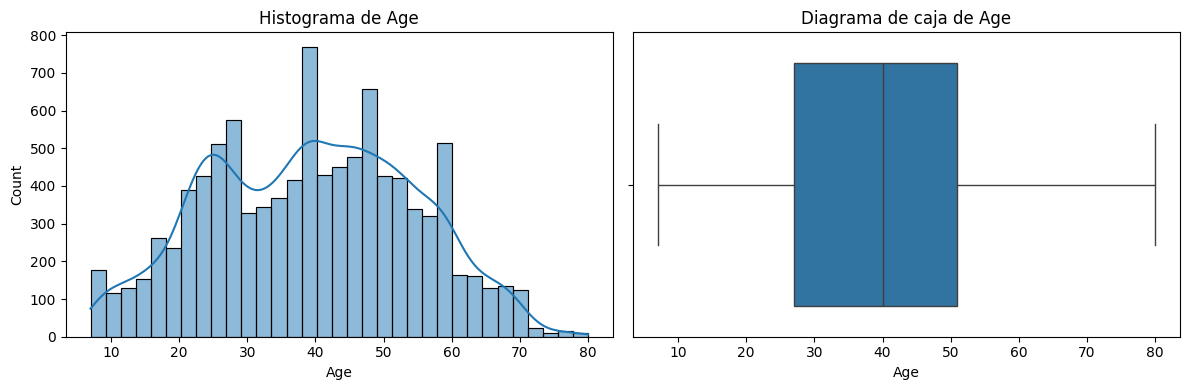

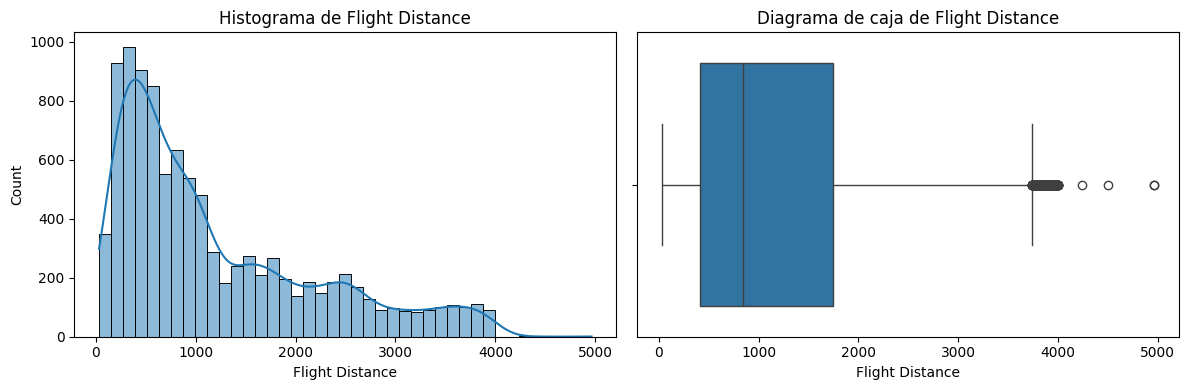

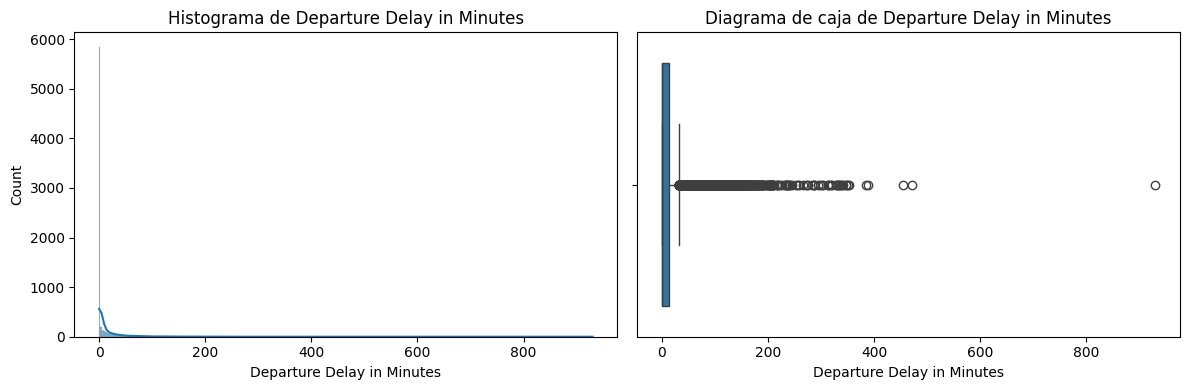

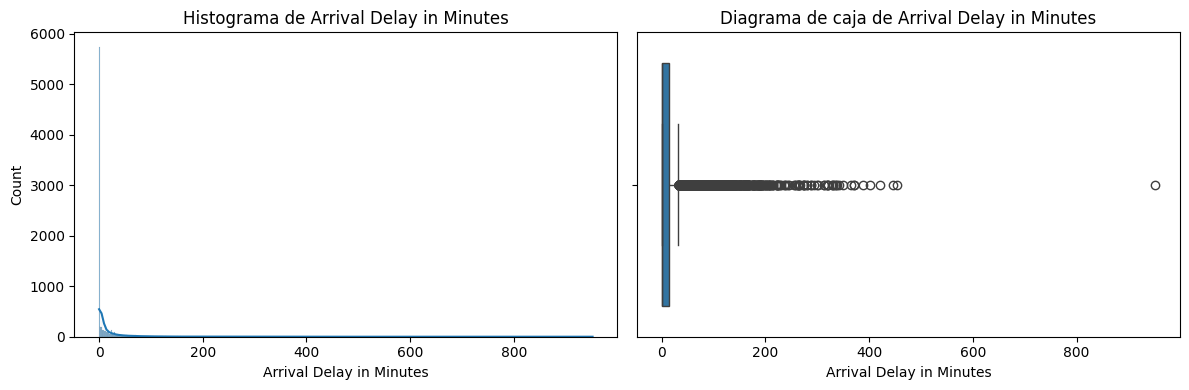

In [5]:
cols_numericas_clave = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

for col in cols_numericas_clave:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f'Histograma de {col}')
    
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f'Diagrama de caja de {col}')
    
    plt.tight_layout()
    plt.show()

Exploramos las variables de calificación (escala 0–5) de forma conjunta, ya que su distribución es ordinal y tiene un comportamiento diferente al de las variables continuas.

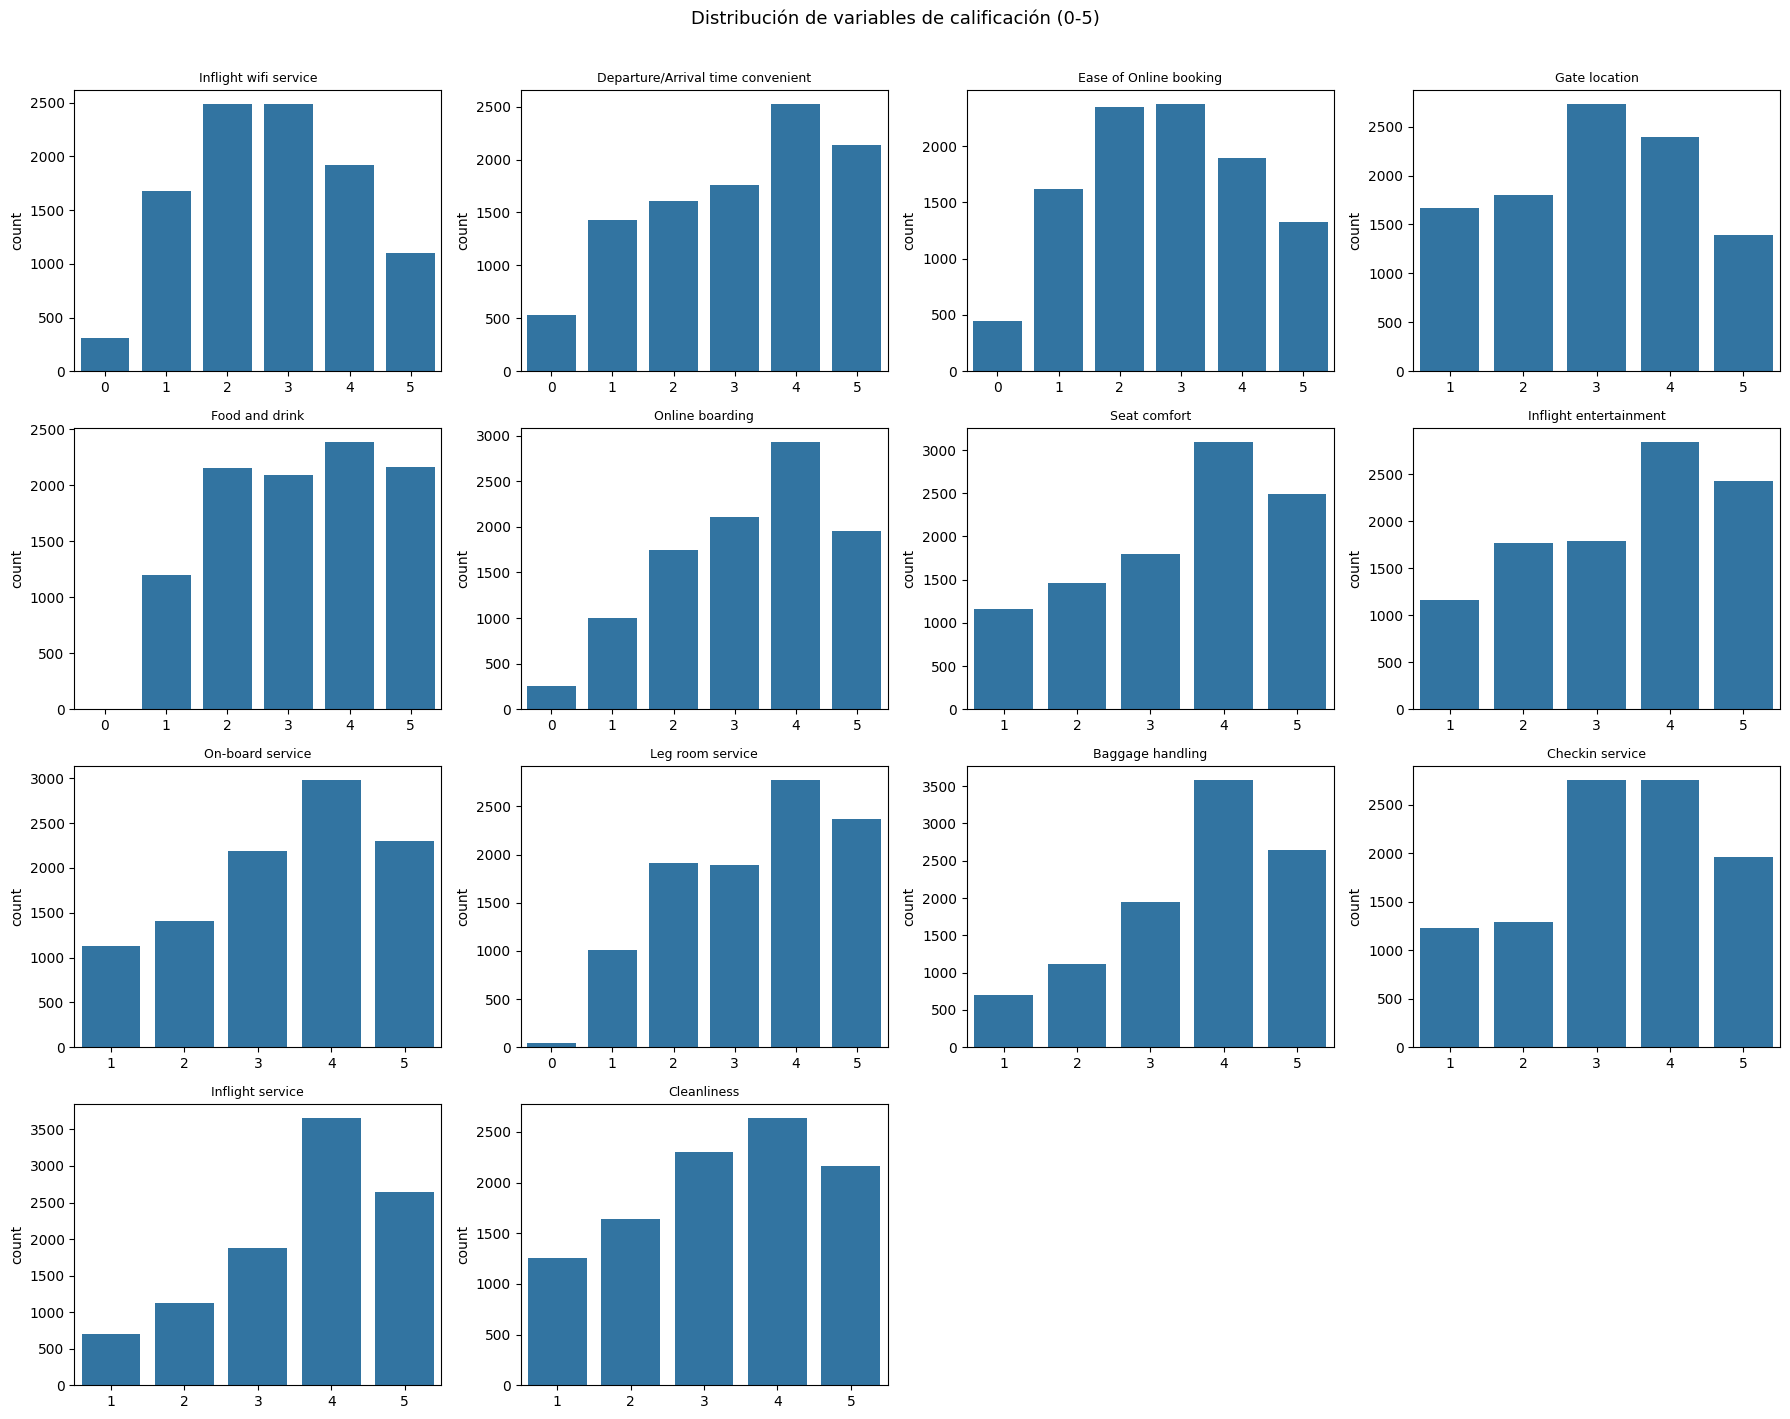

In [6]:
cols_calificaciones = [
    'Inflight wifi service', 'Departure/Arrival time convenient',
    'Ease of Online booking', 'Gate location', 'Food and drink',
    'Online boarding', 'Seat comfort', 'Inflight entertainment',
    'On-board service', 'Leg room service', 'Baggage handling',
    'Checkin service', 'Inflight service', 'Cleanliness'
]

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(cols_calificaciones):
    sns.countplot(x=df[col], ax=axes[i], order=sorted(df[col].dropna().unique()))
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')

for j in range(len(cols_calificaciones), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de variables de calificación (0-5)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Exploración de variables categóricas

Revisamos la distribución de las variables categóricas para identificar desbalances, categorías poco frecuentes o posibles errores de calidad.

,Variable,Número de categorías únicas,Valores faltantes
0,Gender,2,0
1,Customer Type,2,0
2,Type of Travel,2,0
3,Class,3,0



Variable: Gender


,Frecuencia
Gender,
Female,5140
Male,4860


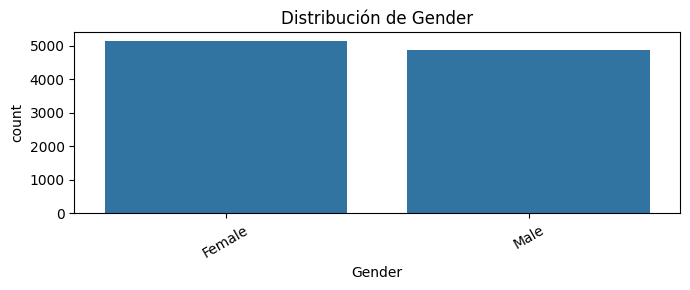


Variable: Customer Type


,Frecuencia
Customer Type,
Loyal Customer,8155
disloyal Customer,1845


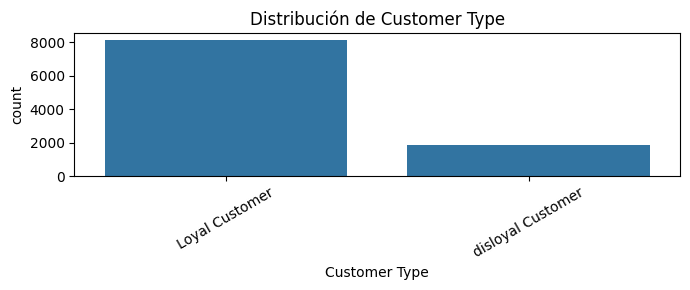


Variable: Type of Travel


,Frecuencia
Type of Travel,
Business travel,6934
Personal Travel,3066


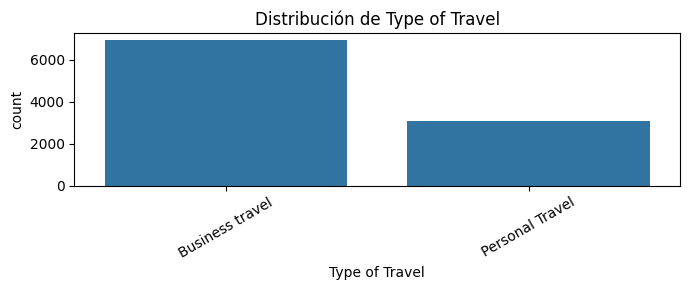


Variable: Class


,Frecuencia
Class,
Business,4856
Eco,4442
Eco Plus,702


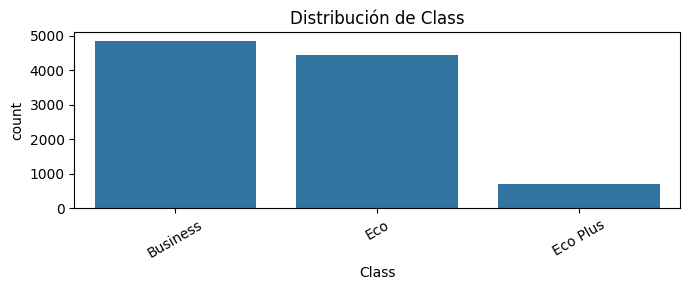

In [7]:
resumen_categoricas = pd.DataFrame({
    'Variable': variables_categoricas,
    'Número de categorías únicas': [df[col].nunique() for col in variables_categoricas],
    'Valores faltantes': [df[col].isnull().sum() for col in variables_categoricas]
})

display(resumen_categoricas)

for col in variables_categoricas:
    print(f'\nVariable: {col}')
    display(df[col].value_counts(dropna=False).to_frame('Frecuencia'))
    
    plt.figure(figsize=(7, 3))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f'Distribución de {col}')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

### Exploración de nulos, duplicados y outliers

In [8]:
# Nulos
valores_nulos = df.isnull().sum()
porcentaje_nulos = ((valores_nulos / len(df)) * 100).round(2)
nulos = pd.DataFrame({'Nulos': valores_nulos, 'Porcentaje (%)': porcentaje_nulos})
print("Variables con nulos:")
display(nulos[nulos['Nulos'] > 0])

# Duplicados
print(f"\nDuplicados idénticos: {df.duplicated().sum()}")

# Outliers IQR — solo variables continuas
continuas = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

for col in continuas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    print(f"\n{col}: {len(outliers)} outliers estadísticos | min={df[col].min()} max={df[col].max()}")

Variables con nulos:


,Nulos,Porcentaje (%)
Arrival Delay in Minutes,25,0.25



Duplicados idénticos: 0

Age: 0 outliers estadísticos | min=7 max=80

Flight Distance: 223 outliers estadísticos | min=31 max=4963

Departure Delay in Minutes: 1337 outliers estadísticos | min=0 max=930

Arrival Delay in Minutes: 1359 outliers estadísticos | min=0.0 max=952.0


### Matriz de correlación entre variables numéricas

Exploramos las relaciones lineales entre las variables numéricas para identificar posibles redundancias o asociaciones relevantes para el análisis de agrupación.

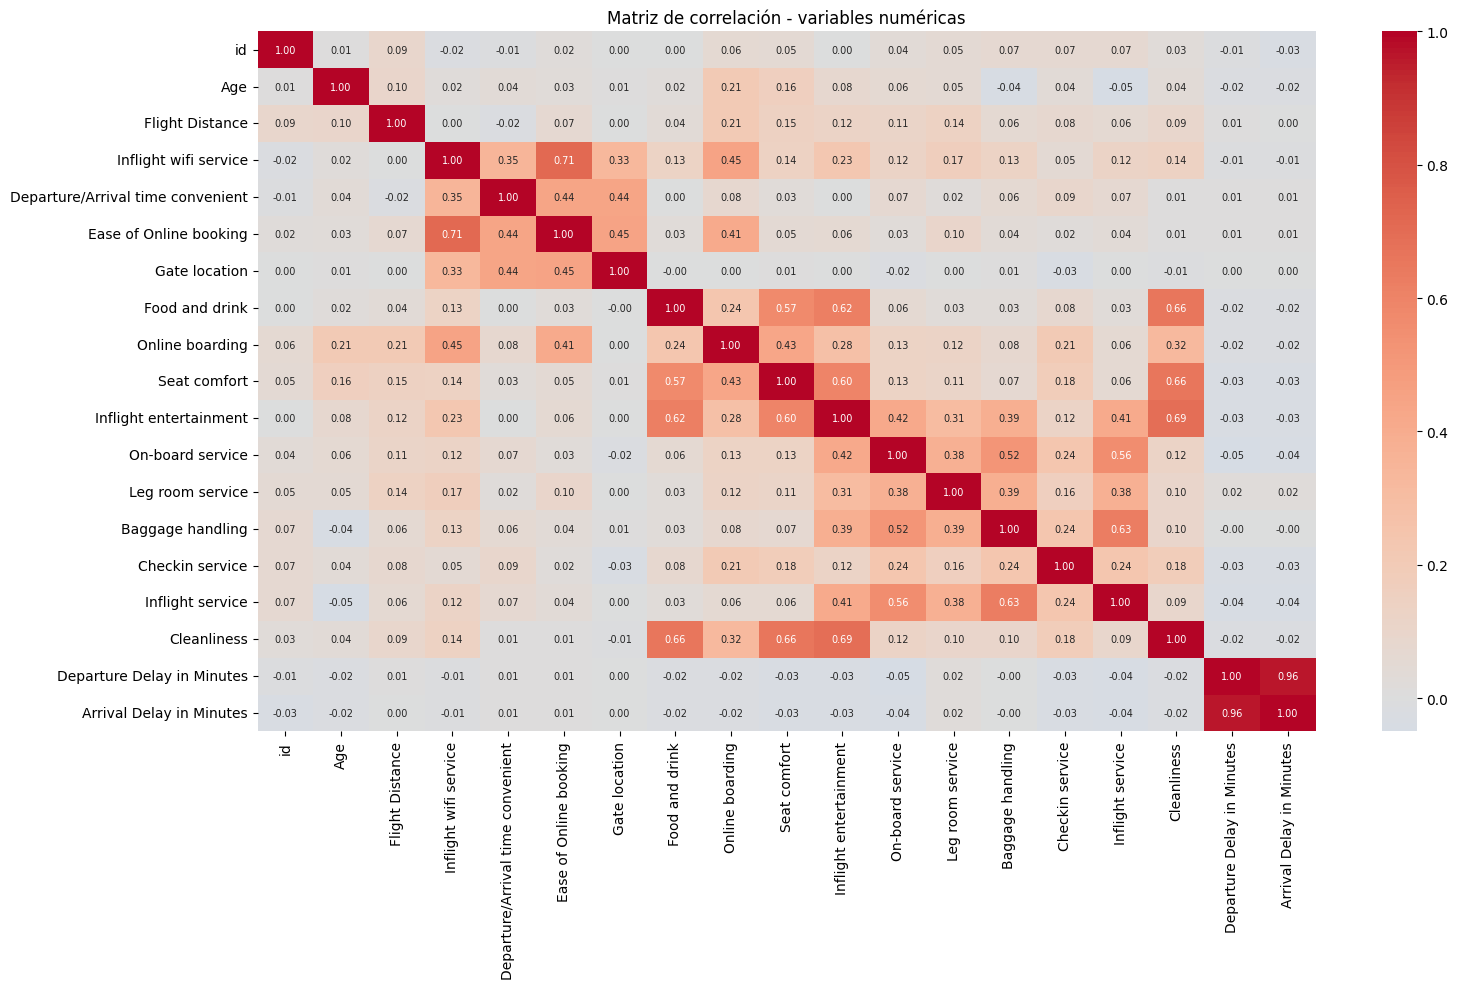

In [9]:
plt.figure(figsize=(16, 10))
sns.heatmap(df.select_dtypes(include='number').corr().round(2),
            annot=True, cmap='coolwarm', center=0, fmt='.2f', annot_kws={"size": 7})
plt.title('Matriz de correlación - variables numéricas')
plt.tight_layout()
plt.show()

### Hallazgos de la exploración de los datos

A partir de la exploración realizada, identificamos los siguientes hallazgos relevantes:

1. Todos los tipos de datos son consistentes con el diccionario. Las variables de calificación 
(escala 0–5) están almacenadas como `int64`, lo cual es correcto numéricamente, pero son 
semánticamente ordinales. La variable `id` es un identificador único que no aporta información 
para el análisis y debe excluirse del modelado.

2. La única variable con valores faltantes es `Arrival Delay in Minutes`, con 25 nulos 
(0.25% del total). Dado que la variable `Departure Delay in Minutes` tiene correlación alta 
con esta variable, se puede imputar con la mediana.

3. No se encontraron duplicados idénticos ni valores imposibles en ninguna variable. Los rangos 
observados (edad entre 7 y 80 años, distancias entre 31 y 4963 km, retrasos entre 0 y 930 
minutos) son plausibles en el contexto de una aerolínea.

4. Las variables `Departure Delay in Minutes` y `Arrival Delay in Minutes` presentan una alta 
concentración de valores cercanos a cero con una cola larga hacia la derecha (distribución 
sesgada), lo que explica la presencia de 1337 y 1359 outliers estadísticos respectivamente. 
Estos valores son posibles desde la lógica del negocio, por lo que no se eliminarán, pero 
se tendrá en cuenta al momento de escalar los datos para el modelado, pues los modelos de clustering son muy sensibles a outliers.

5. `Flight Distance` también presenta 223 outliers estadísticos con una distribución sesgada 
a la derecha, correspondiente a vuelos de larga distancia. Al igual que los retrasos, 
son valores válidos.

6. Las variables de calificación muestran distribuciones variadas: algunas como `Online boarding` 
y `Inflight service` se concentran en valores altos (3–5), mientras que `Inflight wifi service` 
y `Ease of Online booking` presentan distribuciones más uniformes, lo que sugiere mayor 
variabilidad en la percepción de estos servicios entre los pasajeros.

7. La correlación más alta entre variables numéricas se da entre `Departure Delay in Minutes` 
y `Arrival Delay in Minutes`, lo que es lógico: un retraso en salida suele propagarse a la 
llegada. Esta redundancia se considerará en la preparación de datos.

## 2. Preparación de los datos

### Propuesta de limpieza y preparación de los datos

Con base en los hallazgos de la exploración, realizaremos la preparación de los datos para 
los modelos de agrupación. La preparación tiene como objetivos:

1. Corregir los problemas de calidad identificados en la exploración.
2. Adaptar los datos a la tarea de agrupación.
3. Adaptar los datos a cada uno de los tres algoritmos que se van a utilizar.

Implementaremos la preparación de forma modular mediante funciones, con el fin de tener un proceso reutilizable para los tres modelos.

### 2.1. Librerías para la preparación y construcción de preprocesadores

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler

### 2.2. Función de limpieza base

Definimos una función que aplica las decisiones de limpieza tomadas a partir de la exploración.
Las transformaciones aplicadas son:

- Eliminación de `id`, por ser un identificador sin valor informativo para el clustering.
- Eliminación de `Arrival Delay in Minutes`, por su correlación de 0.96 con 
`Departure Delay in Minutes`, lo que la hace redundante.

In [11]:
def limpieza_base_vuelaalpes(df):
    df_clean = df.copy()

    # 1) Eliminar identificador sin valor informativo
    if 'id' in df_clean.columns:
        df_clean = df_clean.drop(columns=['id'])

    # 2) Eliminar variable redundante (correlación 0.96 con Departure Delay)
    if 'Arrival Delay in Minutes' in df_clean.columns:
        df_clean = df_clean.drop(columns=['Arrival Delay in Minutes'])

    return df_clean

### 2.3. Aplicación de la limpieza base

In [12]:
df_clean = limpieza_base_vuelaalpes(df)

print('Dimensiones antes de limpieza base:', df.shape)
print('Dimensiones después de limpieza base:', df_clean.shape)
display(df_clean.head())

Dimensiones antes de limpieza base: (10000, 23)
Dimensiones después de limpieza base: (10000, 21)


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes
0,Male,Loyal Customer,29,Business travel,Business,814,3,3,3,3,4,4,4,4,4,2,5,4,4,4,9
1,Male,Loyal Customer,54,Business travel,Business,2913,4,4,4,4,4,4,4,4,4,4,4,4,4,4,26
2,Male,Loyal Customer,52,Business travel,Eco,277,4,5,5,5,4,4,4,4,4,4,4,3,4,4,68
3,Female,Loyal Customer,17,Personal Travel,Eco,1744,3,0,3,1,4,3,1,4,4,2,5,4,5,4,7
4,Female,Loyal Customer,30,Personal Travel,Eco,1440,3,4,3,2,3,3,3,3,5,5,4,5,4,3,0


### 2.4. Función para construir el preprocesador

Construimos el preprocesador compartido para los tres algoritmos, distinguiendo tres grupos 
de variables según su naturaleza:

- **Variables numéricas continuas** (`Age`, `Flight Distance`, `Departure Delay in Minutes`): 
  escalado con `RobustScaler`.
- **Variables de calificación** (escala 0–5): escalado con `StandardScaler`.
- **Variables categóricas** (`Gender`, `Customer Type`, `Type of Travel`, `Class`): 
  codificación con `OneHotEncoder`.

En todos los grupos se incluye un `SimpleImputer` (imputación de nulos) como medida defensiva.

In [13]:
def construir_preprocesador(df_clean):

    num_continuas = ['Age', 'Flight Distance', 'Departure Delay in Minutes']
    num_calificaciones = [
        'Inflight wifi service', 'Departure/Arrival time convenient',
        'Ease of Online booking', 'Gate location', 'Food and drink',
        'Online boarding', 'Seat comfort', 'Inflight entertainment',
        'On-board service', 'Leg room service', 'Baggage handling',
        'Checkin service', 'Inflight service', 'Cleanliness'
    ]
    cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
    
    # Variables continuas → RobustScaler (distribuciones sesgadas)
    num_transformer_continuas = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', RobustScaler())
    ])
    
    # Variables de calificación → StandardScaler 
    # (rango fijo 0-5, sin outliers extremos, escalado estándar es suficiente)
    num_transformer_calif = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    cat_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    preprocessor = ColumnTransformer(transformers=[
        ('num_continuas', num_transformer_continuas, num_continuas),
        ('num_calificaciones', num_transformer_calif, num_calificaciones),
        ('cat', cat_transformer, cat_cols)
    ])

    return preprocessor

### 2.5. Función compacta de preparación para cada modelo

Creamos una función que recibe el dataset limpio, y devuelve el 
preprocesador listo para integrarse en el pipeline de cada modelo.

In [14]:
def preparar_experimento(df_clean):
    preprocessor = construir_preprocesador(df_clean)
    print(f'Filas: {df_clean.shape[0]} | Columnas de entrada: {df_clean.shape[1]}')
    return {
        'df_clean': df_clean,
        'preprocessor': preprocessor
    }

experimento = preparar_experimento(df_clean)

Filas: 10000 | Columnas de entrada: 21


### 2.6. Justificación de las decisiones de preparación

- Se eliminó `id` por ser un identificador sin valor informativo, y `Arrival Delay in Minutes` 
por su correlación de 0.96 con `Departure Delay in Minutes`, que la hace redundante.

- Se usó `RobustScaler` para las variables continuas porque presentan distribuciones sesgadas 
con valores extremos válidos, este escalador usa la mediana y el IQR, reduciendo el efecto 
de esos outliers sin necesidad de eliminarlos. Para las calificaciones se prefirió 
`StandardScaler` dado su rango fijo (0–5) sin valores extremos. Aunque son ordinales, 
se tratan como numéricas para evitar la explosión de dimensionalidad que generaría 
`OneHotEncoder` (14 variables × 6 categorías = 84 columnas nuevas).

- El `SimpleImputer` se incluye únicamente como medida defensiva, ya que al eliminar 
`Arrival Delay in Minutes` el dataset quedó sin valores faltantes.

## 3. Modelos de Agrupación

### 3.1 Librerías para modelamiento

In [15]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.pipeline import Pipeline
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

### 3.2. Función para construir pipelines de agrupación

Queremos que cada algoritmo quede integrado con el mismo preprocesamiento definido en el literal 2, para así garantizar un flujo ordenado, reproducible y comparable, primero se limpian y se preparan los datos, luego se aplica el modelo de agrupación.

In [16]:
def construir_pipeline_agrupacion(preprocessor, modelo):
    """
    Construye un pipeline reproducible que integra
    1. Preprocesamiento de datos
    2. Modelo de agrupación
    """
    pipeline = Pipeline(steps=[
        ('preprocesamiento', preprocessor),
        ('modelo', modelo)
    ])
    
    return pipeline

### 3.3. Función para evaluar una agrupación

Como vamos a trabajar con aprendizaje no supervisado, no tenemos una etiqueta real contra la cual comparar, es por que eso que necesitamos usar métricas, las escogidas fueron: 

**Silhouette**: Mide qué tan compactos y separados están los grupos, **mayor es mejor**.
**Calinski-Harabasz**: Mide la separación entre grupos respecto a compactación interna, **mayor es mejor**.
**Davies-Bouldin**: Mide similitud entre grupos, **menor es mejor**.

**Nota**: Calinsku y Bouldin no las vimos en clase, pero como no tenemos una variable objetivo, buscamos otras formas complementarias de medir el rendimiento de los modelos. 

En el caso de DBSCAN, la etiqueta -1 representa ruido o datos extremos.
Para evaluar la calidad de los grupos, calculamos las métricas solo sobre los puntos que sí fueron asignados a un grupo.

In [17]:
def evaluar_agrupacion(X_transformado, labels, nombre_modelo, parametros, sample_size=3000, random_state=42):
    """
    Evalúa una agrupación usando métricas vistas en clase:
    - Coeficiente de silueta.
    - Inercia, cuando aplica para K-Means.

    También reporta ruido para DBSCAN, donde la etiqueta -1 representa datos extremos/no asignados.
    """
    labels = np.asarray(labels)
    total_observaciones = len(labels)

    # DBSCAN usa -1 para ruido
    n_ruido = int(np.sum(labels == -1))
    prop_ruido = n_ruido / total_observaciones

    # Para evaluar silueta excluimos ruido, si existe
    mascara_evaluacion = labels != -1
    X_eval = X_transformado[mascara_evaluacion]
    labels_eval = labels[mascara_evaluacion]

    # Si DBSCAN marcó todo como ruido, no se puede evaluar
    if len(labels_eval) == 0:
        return {
            'modelo': nombre_modelo,
            'parametros': parametros,
            'n_clusters': 0,
            'n_ruido': n_ruido,
            'prop_ruido': prop_ruido,
            'silhouette': np.nan
        }

    n_clusters = len(np.unique(labels_eval))

    # Silhouette necesita mínimo 2 grupos y máximo n_samples - 1 grupos
    if n_clusters < 2 or n_clusters >= len(labels_eval):
        return {
            'modelo': nombre_modelo,
            'parametros': parametros,
            'n_clusters': n_clusters,
            'n_ruido': n_ruido,
            'prop_ruido': prop_ruido,
            'silhouette': np.nan
        }

    n_sample = min(sample_size, len(labels_eval))

    silhouette = silhouette_score(
        X_eval,
        labels_eval,
        sample_size=n_sample,
        random_state=random_state
    )

    return {
        'modelo': nombre_modelo,
        'parametros': parametros,
        'n_clusters': n_clusters,
        'n_ruido': n_ruido,
        'prop_ruido': prop_ruido,
        'silhouette': silhouette
    }

### 3.4. Función general para buscar hiperparámetros

En este literal, definimos una función que prueba diferentes combinaciones de hiperparámetros para cada algoritmo, como no tenemos variable objetivo, no usamos GridSearchCV, sino que hacemos una búsqueda manual con ParameterGrid y vamos a tomar la mejor configuración según el coeficiente de silueta. Para que el proceso sea más liviano y reproducible, la búsqueda se hace solamente sobre una muestra del dataset.

In [18]:
def buscar_hiperparametros_agrupacion(
    df_clean,
    preprocessor,
    nombre_modelo,
    constructor_modelo,
    param_grid,
    max_tuning_rows=5000,
    random_state=42
):
    """
    Busca hiperparámetros para un algoritmo de agrupación.

    """
    
    # Muestra para hacer la búsqueda más eficiente
    if len(df_clean) > max_tuning_rows:
        df_tuning = df_clean.sample(n=max_tuning_rows, random_state=random_state)
    else:
        df_tuning = df_clean.copy()
    
    resultados = []
    
    for parametros in ParameterGrid(param_grid):
        modelo = constructor_modelo(**parametros)
        pipeline = construir_pipeline_agrupacion(preprocessor, modelo)
        
        try:
            labels = pipeline.fit_predict(df_tuning)
            X_transformado = pipeline.named_steps['preprocesamiento'].transform(df_tuning)
            
            resultado = evaluar_agrupacion(
                X_transformado=X_transformado,
                labels=labels,
                nombre_modelo=nombre_modelo,
                parametros=parametros,
                random_state=random_state
            )
            
            resultados.append(resultado)
        
        except Exception as e:
            resultados.append({
                'modelo': nombre_modelo,
                'parametros': parametros,
                'n_clusters': np.nan,
                'n_ruido': np.nan,
                'prop_ruido': np.nan,
                'silhouette': np.nan,
                'calinski_harabasz': np.nan,
                'davies_bouldin': np.nan,
                'error': str(e)
            })
    
    resultados_df = pd.DataFrame(resultados)
    resultados_df = resultados_df.sort_values(
        by='silhouette',
        ascending=False,
        na_position='last'
    ).reset_index(drop=True)
    
    return resultados_df

### 3.5. Definición de los tres algoritmos y sus hiperparámetros

Seleccionamos tres enfoques distintos de agrupación:

- **K-Means**: Algoritmo basado en centroides, requiere definir el número de grupos.
- **Agglomerative Clustering**: Algoritmo jerárquico aglomerativo, nos permite comparar diferentes formas de enlace entre grupos.
- **DBSCAN**: Algoritmo basado en densidad, nos permite identificar grupos densos y datos ruidosos.

In [19]:
def crear_kmeans(n_clusters, random_state=42):
    return KMeans(
        n_clusters=n_clusters,
        n_init=10,
        max_iter=300,
        random_state=random_state
    )


def crear_agglomerative(n_clusters, linkage):
    return AgglomerativeClustering(
        n_clusters=n_clusters,
        linkage=linkage
    )


def crear_dbscan(eps, min_samples):
    return DBSCAN(
        eps=eps,
        min_samples=min_samples
    )


grid_kmeans = {
    'n_clusters': range(2, 9)
}

grid_agglomerative = {
    'n_clusters': range(2, 9),
    'linkage': ['ward', 'complete', 'average']
}

grid_dbscan = {
    'eps': [5.0, 10.0, 15.0, 20.0], # Valores más altos
    'min_samples': [5, 10, 20]
}



### 3.6. Búsqueda de hiperparámetros para K-Means

K-Means busca grupos compactos alrededor de centroides, asì que en este caso el hiperparámetro principal es n_clusters, es decir, el número de grupos que se desea construir.

In [20]:
resultados_kmeans = buscar_hiperparametros_agrupacion(
    df_clean=experimento['df_clean'],
    preprocessor=experimento['preprocessor'],
    nombre_modelo='KMeans',
    constructor_modelo=crear_kmeans,
    param_grid=grid_kmeans
)

display(resultados_kmeans)

,modelo,parametros,n_clusters,n_ruido,prop_ruido,silhouette
0,KMeans,{'n_clusters': 2},2,0,0.0,0.474914
1,KMeans,{'n_clusters': 3},3,0,0.0,0.151353
2,KMeans,{'n_clusters': 5},5,0,0.0,0.123800
3,KMeans,{'n_clusters': 6},6,0,0.0,0.123693
4,KMeans,{'n_clusters': 4},4,0,0.0,0.121704
5,KMeans,{'n_clusters': 7},7,0,0.0,0.121211
6,KMeans,{'n_clusters': 8},8,0,0.0,0.120809


### 3.7. Búsqueda de hiperparámetros para agrupación Agglomerative Clustering

Este algoritmo construye grupos de forma jerárquica, uniendo grupos cercanos, entonces probamos distintos valores de n_clusters y diferentes criterios de enlace.

In [21]:
resultados_agglomerative = buscar_hiperparametros_agrupacion(
    df_clean=experimento['df_clean'],
    preprocessor=experimento['preprocessor'],
    nombre_modelo='AgglomerativeClustering',
    constructor_modelo=crear_agglomerative,
    param_grid=grid_agglomerative
)

display(resultados_agglomerative)

,modelo,parametros,n_clusters,n_ruido,prop_ruido,silhouette
0,AgglomerativeClustering,"{'linkage': 'complete', 'n_clusters': 2}",2,0,0.0,0.725787
1,AgglomerativeClustering,"{'linkage': 'average', 'n_clusters': 2}",2,0,0.0,0.701655
2,AgglomerativeClustering,"{'linkage': 'average', 'n_clusters': 3}",3,0,0.0,0.690778
3,AgglomerativeClustering,"{'linkage': 'complete', 'n_clusters': 3}",3,0,0.0,0.512228
4,AgglomerativeClustering,"{'linkage': 'ward', 'n_clusters': 2}",2,0,0.0,0.504789
5,AgglomerativeClustering,"{'linkage': 'complete', 'n_clusters': 4}",4,0,0.0,0.474594
6,AgglomerativeClustering,"{'linkage': 'complete', 'n_clusters': 5}",5,0,0.0,0.474559
7,AgglomerativeClustering,"{'linkage': 'average', 'n_clusters': 4}",4,0,0.0,0.414116
8,AgglomerativeClustering,"{'linkage': 'average', 'n_clusters': 5}",5,0,0.0,0.320919
9,AgglomerativeClustering,"{'linkage': 'average', 'n_clusters': 6}",6,0,0.0,0.320112


### 3.8. Búsqueda de hiperparámetros para DBSCAN

DBSCAN identifica grupos como regiones densas y sus hiperparámetros principales son:

**eps**: Radio de vecindad
**min_samples**: Cantidad mínima de observaciones necesarias para formar una región densa

A diferencia de K-Means y el Agglomerative Clusterinf, DBSCAN puede detectar ruido usando la etiqueta -1.

In [22]:
resultados_dbscan = buscar_hiperparametros_agrupacion(
    df_clean=experimento['df_clean'],
    preprocessor=experimento['preprocessor'],
    nombre_modelo='DBSCAN',
    constructor_modelo=crear_dbscan,
    param_grid=grid_dbscan
)

display(resultados_dbscan)

,modelo,parametros,n_clusters,n_ruido,prop_ruido,silhouette
0,DBSCAN,"{'eps': 5.0, 'min_samples': 5}",1,6,0.0012,NaN
1,DBSCAN,"{'eps': 5.0, 'min_samples': 10}",1,12,0.0024,NaN
2,DBSCAN,"{'eps': 5.0, 'min_samples': 20}",1,23,0.0046,NaN
3,DBSCAN,"{'eps': 10.0, 'min_samples': 5}",1,0,0.0000,NaN
4,DBSCAN,"{'eps': 10.0, 'min_samples': 10}",1,0,0.0000,NaN
5,DBSCAN,"{'eps': 10.0, 'min_samples': 20}",1,0,0.0000,NaN
6,DBSCAN,"{'eps': 15.0, 'min_samples': 5}",1,0,0.0000,NaN
7,DBSCAN,"{'eps': 15.0, 'min_samples': 10}",1,0,0.0000,NaN
8,DBSCAN,"{'eps': 15.0, 'min_samples': 20}",1,0,0.0000,NaN
9,DBSCAN,"{'eps': 20.0, 'min_samples': 5}",1,0,0.0000,NaN


### 3.9. Comparación inicial de los mejores resultados

Consolidamos el mejor resultado de cada algoritmo según el coeficiente de silueta, lo hacemos para tener una vista general por ahora, más adelante haremos una comparación a fondo.

In [23]:
def obtener_mejor_resultado(resultados_df):
    """
    Selecciona la mejor configuración según silhouette.
    Si ningún resultado tiene silhouette válido, conserva el primer resultado
    para reportar que el modelo no produjo una agrupación evaluable.
    """
    resultados_validos = resultados_df.dropna(subset=['silhouette']).copy()

    if not resultados_validos.empty:
        return resultados_validos.sort_values(
            by='silhouette',
            ascending=False
        ).iloc[0]

    # Si no hay silhouette válido, igual devolvemos una fila para reportar el caso
    return resultados_df.iloc[0]


mejores_resultados = []

for resultados in [resultados_kmeans, resultados_agglomerative, resultados_dbscan]:
    mejor = obtener_mejor_resultado(resultados)
    if mejor is not None:
        mejores_resultados.append(mejor)

tabla_mejores_modelos = pd.DataFrame(mejores_resultados).reset_index(drop=True)

display(tabla_mejores_modelos)

,modelo,parametros,n_clusters,n_ruido,prop_ruido,silhouette
0,KMeans,{'n_clusters': 2},2,0,0.0000,0.474914
1,AgglomerativeClustering,"{'linkage': 'complete', 'n_clusters': 2}",2,0,0.0000,0.725787
2,DBSCAN,"{'eps': 5.0, 'min_samples': 5}",1,6,0.0012,NaN


### 3.10. Ajuste final de los mejores modelos sobre todo el conjunto de datos

Después de seleccionar la mejor configuración para cada algoritmo, ajustamos cada modelo usando todo el conjunto, y guardamos las etiquetas de grupo generadas para poder revisarlas después.

In [24]:
def calcular_metricas_finales_seguro(X_transformado, labels, nombre_modelo, parametros, sample_size=3000, random_state=42):
    labels = np.asarray(labels)
    total = len(labels)

    # Solo DBSCAN usa -1 como ruido
    if nombre_modelo == 'DBSCAN':
        n_ruido = int(np.sum(labels == -1))
        prop_ruido = n_ruido / total if total > 0 else np.nan

        mascara = labels != -1
        X_eval = X_transformado[mascara]
        labels_eval = labels[mascara]
    else:
        n_ruido = 0
        prop_ruido = 0.0

        X_eval = X_transformado
        labels_eval = labels

    n_clusters = len(np.unique(labels_eval))
    n_muestras = len(labels_eval)

    silhouette = np.nan

    if n_muestras > 0 and n_clusters >= 2 and n_clusters < n_muestras:
        try:
            n_sample = min(sample_size, n_muestras)
            silhouette = silhouette_score(
                X_eval,
                labels_eval,
                sample_size=n_sample,
                random_state=random_state
            )
        except Exception as e:
            print(f"No se pudo calcular silhouette para {nombre_modelo}: {e}")

    return {
        'modelo': nombre_modelo,
        'parametros': parametros,
        'n_clusters': n_clusters,
        'n_ruido': n_ruido,
        'prop_ruido': prop_ruido,
        'silhouette': silhouette
    }


modelos_finales = {}
metricas_finales = []

constructores = {
    'KMeans': crear_kmeans,
    'AgglomerativeClustering': crear_agglomerative,
    'DBSCAN': crear_dbscan
}

for _, fila in tabla_mejores_modelos.iterrows():
    nombre_modelo = fila['modelo']
    parametros = fila['parametros']

    print(f"Ajustando modelo final: {nombre_modelo} con {parametros}")

    modelo = constructores[nombre_modelo](**parametros)
    pipeline_final = construir_pipeline_agrupacion(
        experimento['preprocessor'],
        modelo
    )

    labels_finales = pipeline_final.fit_predict(experimento['df_clean'])
    X_transformado = pipeline_final.named_steps['preprocesamiento'].transform(experimento['df_clean'])

    metricas = calcular_metricas_finales_seguro(
        X_transformado=X_transformado,
        labels=labels_finales,
        nombre_modelo=nombre_modelo,
        parametros=parametros
    )

    modelos_finales[nombre_modelo] = {
        'pipeline': pipeline_final,
        'labels': labels_finales,
        'parametros': parametros
    }

    metricas_finales.append(metricas)

tabla_metricas_finales = pd.DataFrame(metricas_finales).sort_values(
    by='silhouette',
    ascending=False,
    na_position='last'
).reset_index(drop=True)

display(tabla_metricas_finales)

Ajustando modelo final: KMeans con {'n_clusters': 2}
Ajustando modelo final: AgglomerativeClustering con {'linkage': 'complete', 'n_clusters': 2}
No se pudo calcular silhouette para AgglomerativeClustering: Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)
Ajustando modelo final: DBSCAN con {'eps': 5.0, 'min_samples': 5}


,modelo,parametros,n_clusters,n_ruido,prop_ruido,silhouette
0,KMeans,{'n_clusters': 2},2,0,0.0000,0.476332
1,AgglomerativeClustering,"{'linkage': 'complete', 'n_clusters': 2}",2,0,0.0000,NaN
2,DBSCAN,"{'eps': 5.0, 'min_samples': 5}",1,5,0.0005,NaN


### 3.11. Selección del mejor modelo de agrupación

Seleccionamos como mejor modelo inicial el que tenga el mayor coeficiente de silueta, un número de grupos razonable y, en el caso de DBSCAN, que no marque demasiados datos como ruido.

In [25]:
mejor_modelo_nombre = tabla_metricas_finales.iloc[0]['modelo']
mejor_modelo_info = modelos_finales[mejor_modelo_nombre]

print('Mejor modelo seleccionado:', mejor_modelo_nombre)
print('Hiperparámetros:', mejor_modelo_info['parametros'])

df_clusterizado = experimento['df_clean'].copy()
df_clusterizado['cluster'] = mejor_modelo_info['labels']

display(df_clusterizado.head())
display(df_clusterizado['cluster'].value_counts().sort_index().to_frame('Cantidad de pasajeros'))

Mejor modelo seleccionado: KMeans
Hiperparámetros: {'n_clusters': 2}


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,cluster
0,Male,Loyal Customer,29,Business travel,Business,814,3,3,3,3,4,4,4,4,4,2,5,4,4,4,9,1
1,Male,Loyal Customer,54,Business travel,Business,2913,4,4,4,4,4,4,4,4,4,4,4,4,4,4,26,1
2,Male,Loyal Customer,52,Business travel,Eco,277,4,5,5,5,4,4,4,4,4,4,4,3,4,4,68,1
3,Female,Loyal Customer,17,Personal Travel,Eco,1744,3,0,3,1,4,3,1,4,4,2,5,4,5,4,7,1
4,Female,Loyal Customer,30,Personal Travel,Eco,1440,3,4,3,2,3,3,3,3,5,5,4,5,4,3,0,1


,Cantidad de pasajeros
cluster,
0,607
1,9393


## 4. Evaluació cuantitativa

### 4.1 Criterio

La evaluación cuantitativa de los modelos de agrupación la vamos a hacer usando métricas intrínsecas, debido a que estamos trabajando con aprendizaje no supervisado y no tenemos una variable objetivo. La métrica va a ser el coeficiente de silueta, un valor cercano a 1 indica grupos compactos y bien separados, mientras que valores cercanos a 0 implica lo contrario.

Adicionalmente, vamos a usar dos métricas complementarias, Calinski-Harabasz y Davies-Bouldin, estas métricas no serán el criterio principal de selección, pero las tendremos en cuenta para poder contrastar los resultados desde otors criterios.

### 4.2 Función para calcular métricas cuantitativas finales

Definimos una función que calcula las métricas sobre los resultados finales de cada modelo, en el caso de DBSCAN, se excluyen los datos etiquetados como ruido (-1) para calcular las métricas, pues esos puntos no pertenecen a ningún grupo.

In [26]:
def calcular_metricas_cuantitativas(X_transformado, labels, nombre_modelo, parametros, sample_size=3000, random_state=42):
    """
    Calcula métricas cuantitativas intrínsecas para modelos de agrupación.
    
    Métrica principal:
    - Coeficiente de silueta.
    
    Métricas complementarias:
    - Calinski-Harabasz.
    - Davies-Bouldin.
    """
    labels = np.asarray(labels)
    total_observaciones = len(labels)

    # DBSCAN usa la etiqueta -1 para representar ruido
    if nombre_modelo == 'DBSCAN':
        n_ruido = int(np.sum(labels == -1))
        prop_ruido = n_ruido / total_observaciones if total_observaciones > 0 else np.nan
        
        mascara = labels != -1
        X_eval = X_transformado[mascara]
        labels_eval = labels[mascara]
    else:
        n_ruido = 0
        prop_ruido = 0.0
        X_eval = X_transformado
        labels_eval = labels

    n_clusters = len(np.unique(labels_eval))
    n_muestras = len(labels_eval)

    metricas = {
        'modelo': nombre_modelo,
        'hiperparametros_optimizados': parametros,
        'n_clusters': n_clusters,
        'n_ruido': n_ruido,
        'prop_ruido': prop_ruido,
        'silhouette': np.nan,
        'calinski_harabasz': np.nan,
        'davies_bouldin': np.nan
    }

    # Las métricas requieren al menos 2 grupos válidos
    if n_muestras > 0 and n_clusters >= 2 and n_clusters < n_muestras:
        try:
            n_sample = min(sample_size, n_muestras)

            metricas['silhouette'] = silhouette_score(
                X_eval,
                labels_eval,
                sample_size=n_sample,
                random_state=random_state
            )

            metricas['calinski_harabasz'] = calinski_harabasz_score(
                X_eval,
                labels_eval
            )

            metricas['davies_bouldin'] = davies_bouldin_score(
                X_eval,
                labels_eval
            )

        except Exception as e:
            print(f"No se pudieron calcular las métricas para {nombre_modelo}: {e}")

    return metricas

### 4.3. Tabla comparativa de los tres algoritmos

Definimos una función que construye una tabla comparativa con los tres algoritmos evaluados, esta tabla incluye los hiperparámetros optimizados, el número de grupos generados, la cantidad de ruido y las métricas cuantitativas calculadas.

In [27]:
metricas_comparacion = []

for nombre_modelo, info_modelo in modelos_finales.items():
    pipeline = info_modelo['pipeline']
    labels = info_modelo['labels']
    parametros = info_modelo['parametros']

    X_transformado = pipeline.named_steps['preprocesamiento'].transform(
        experimento['df_clean']
    )

    metricas = calcular_metricas_cuantitativas(
        X_transformado=X_transformado,
        labels=labels,
        nombre_modelo=nombre_modelo,
        parametros=parametros
    )

    metricas_comparacion.append(metricas)

tabla_comparacion_modelos = pd.DataFrame(metricas_comparacion)

tabla_comparacion_modelos = tabla_comparacion_modelos.sort_values(
    by='silhouette',
    ascending=False,
    na_position='last'
).reset_index(drop=True)

display(tabla_comparacion_modelos)

No se pudieron calcular las métricas para AgglomerativeClustering: Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)


,modelo,hiperparametros_optimizados,n_clusters,n_ruido,prop_ruido,silhouette,calinski_harabasz,davies_bouldin
0,KMeans,{'n_clusters': 2},2,0,0.0000,0.476332,2567.354175,1.064675
1,AgglomerativeClustering,"{'linkage': 'complete', 'n_clusters': 2}",2,0,0.0000,NaN,NaN,NaN
2,DBSCAN,"{'eps': 5.0, 'min_samples': 5}",1,5,0.0005,NaN,NaN,NaN


### 4.4. Interpretación de los resultados

In [28]:
mejor_modelo_cuantitativo = tabla_comparacion_modelos.dropna(
    subset=['silhouette']
).iloc[0]

print("Mejor modelo según coeficiente de silueta:")
print("Modelo:", mejor_modelo_cuantitativo['modelo'])
print("Hiperparámetros:", mejor_modelo_cuantitativo['hiperparametros_optimizados'])
print("Coeficiente de silueta:", mejor_modelo_cuantitativo['silhouette'])

Mejor modelo según coeficiente de silueta:
Modelo: KMeans
Hiperparámetros: {'n_clusters': 2}
Coeficiente de silueta: 0.4763317768828055


A partir de la tabla comparativa, podemos ver que el único modelo que logró una agrupación final evaluable con las métricas cuantitativas fue KMeans, este modelo, con el hiperparámetro optimizado n_clusters = 2, obtuvo un coeficiente de silueta de **0.4763**, ese valor sugiere que los grupos tienen una separación razonable. 

En el caso de AgglomerativeClustering, teniamos la configuración linkage = 'complete' y n_clusters = 2, pero no fue posible calcular las métricas finales, eso se debe a que el modelo produjo una sola etiqueta válida, así que no cumplió con las condiciones para calcularle un coeficiente de silueta. 

Por otro lado, DBSCAN, con eps = 5.0 y min_samples = 5, identificó únicamente un grupo válido y marcó 5 observaciones como ruido, debido a que el modelo no generó al menos dos grupos válidos, tampoco fue posible calcular el coeficiente de silueta. Este resultado sugiere que DBSCAN no encontró regiones densas suficientemente separadas para construir una segmentación útil.

Con base en estos resultados, se seleccionó **KMeans con 2 grupos** como el mejor modelo cuantitativo, esta decisión se tomó porque fue el único modelo que generó una agrupación final evaluable y obtuvo valores válidos para las métricas consideradas. 

La distribución de pasajeros muestra que el grupo 0 contiene 607 pasajeros, equivalentes al 6.07% de los datos, mientras que el grupo 1 contiene 9393 pasajeros, equivalentes al 93.93%, la distribución es desbalanceada, pero ambos grupos tienen un tamaño suficiente para ser interpretados.

### 4.5. Tabla de distribución de pasajeros por grupo del mejor modelo

Esta tabla permite revisar cuántos pasajeros quedaron asignados a cada grupo del mejor modelo, esto es importante porque un buen modelo de agrupación no solo debe tener una métrica aceptable, sino también generar grupos interpretables y útiles para la organización.

In [29]:
nombre_mejor_modelo = mejor_modelo_cuantitativo['modelo']
labels_mejor_modelo = modelos_finales[nombre_mejor_modelo]['labels']

df_clusterizado = experimento['df_clean'].copy()
df_clusterizado['cluster'] = labels_mejor_modelo

tabla_distribucion_clusters = (
    df_clusterizado['cluster']
    .value_counts()
    .sort_index()
    .reset_index()
)

tabla_distribucion_clusters.columns = ['cluster', 'cantidad_pasajeros']
tabla_distribucion_clusters['proporcion'] = (
    tabla_distribucion_clusters['cantidad_pasajeros'] / len(df_clusterizado)
)

display(tabla_distribucion_clusters)

,cluster,cantidad_pasajeros,proporcion
0,0,607,0.0607
1,1,9393,0.9393


## 5. Evaluación cualitativa

## 6. Análisis de resultados
1. ¿Qué restricciones tiene cada uno de los algoritmos seleccionados? ¿Cómo afectan estas restricciones la calidad de la solución obtenida?

Cada algoritmo tuvo sus propias limitaciones:

- KMeans necesita que uno le diga desde antes cuántos grupos quiere formar, en nuestro caso, el mejor resultado fue con 2 grupos. También depende mucho de las distancias entre los datos, por eso fue importante escalar y preparar bien las variables antes de usar este algoritmo.

- AgglomerativeClustering también necesita definir el número de grupos y depende del tipo de enlace usado, aunque lo probamos con n_clusters = 2 y linkage = complete, al final no produjo una agrupación que se pudiera evaluar bien con las métricas, entonces no fue  útil para este caso.

- DBSCAN depende mucho de eps y min_samples, en nuestro caso, terminó encontrando prácticamente un solo grupo y solo marcó 5 datos como ruido, así que tampoco sirvió para separar pasajeros en perfiles diferentes.

2. ¿Qué criterios son importantes para la selección del algoritmo?

Para escoger el mejor algoritmo miramos principalmente tres cosas:

- Primero, que el modelo sí formara más de un grupo, si solo formaba un grupo, no nos ayudaba a segmentar pasajeros.

- Segundo, que tuviera una buena métrica de evaluación.

- Tercero, que los grupos se puedan interpretar, porque no sirve mucho tener un modelo con buenas métricas si  no podemos explicar qué significa cada grupo.

Por eso escogimos **KMeans**, porque fue el único que generó una agrupación final evaluable y entendible.

3. ¿Cómo medir la calidad del modelo construido? ¿Cómo saber que el modelo construido tiene una buena calidad?

La calidad del modelo la medimos con métricas internas de agrupación, porque no tenemos una etiqueta real que diga a qué grupo pertenece cada pasajero. La métrica principal fue el coeficiente de silueta, en KMeans obtuvimos un valor de 0.4763, esto nos muestra una separación moderada entre los grupos.


Además, revisamos cuántos pasajeros quedaron en cada grupo, los resultados de KMeans fueron:

**Grupo 0**: 607 pasajeros
**Grupo 1**: 9393 pasajeros

Aunque los grupos están desbalanceados, ambos se pueden analizar.

4. ¿Cómo varía la calidad de la solución obtenida si se aplican diferentes algoritmos?

La calidad cambió bastante dependiendo del algoritmo, por un lado, KMeans fue el mejor porque generó 2 grupos y pudimos calcular las métricas, AgglomerativeClustering fue probado, pero al final no lo pudimos evaluar bien, entonces no fue seleccionado.
Finalmente, DBSCAN no funcionó bien para este caso porque encontró solo un grupo válido. 

En resumen, no todos los algoritmos sirven igual para todos los datos, eso se debe principalmente a la distribución de los datos, por ejemplo, DBSCAN necesitaba datos densos para poder agruparlos. 

5. ¿Cómo interpretar el resultado de la ejecución de los algoritmos de agrupación seleccionados?

Como este es un problema de aprendizaje no supervisado, los grupos no vienen con nombre, así que el algoritmo solo puede afruparlo, y es nuestro deber interpretar qué significa cada grupo.

De los 2 grupos que encontró KMeans:

- El grupo 0 tiene 607 pasajeros, es muy pequeño, así que puede representar un perfil más específico o diferente dentro de los clientes.

- El grupo 1 tiene 9393 pasajeros, es el grupo más grande y seguramente representa el comportamiento más común de los pasajeros.


## Uso de la IAg